<h1><b>2. Principal Component Analysis of Fruits </b></h1>

2 (a) To extract features from each image in the training data, SIFT (Scale-invariant feature transform) is employed. To make sure SIFT gives us 128 dimensions per image keypoint, the image is first converted to greyscale.

In [1]:
import numpy as np
import cv2 as cv
 
img = cv.imread('Fruit-Subset/Training/Apple Golden 1/0_100.jpg')
gray= cv.cvtColor(img,cv.COLOR_BGR2GRAY)
 
sift = cv.SIFT_create()
kp = sift.detect(gray,None)
 
img=cv.drawKeypoints(gray,kp,img)
 
cv.imwrite('sift_keypoints.jpg',img)

True

The following image results from taking the 128 dimensional keypoints of the first golden apple image.

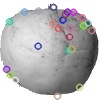

2 (b) A keypoints dataset KP is created below such that it contains all the keypoints from all the training images.

In [2]:
import os

def extract_all_sift_features(image_folder):
    sift = cv.SIFT_create()
    all_features = []
    
    for root, dirs, files in os.walk(image_folder):
        for file in files:
            if file.endswith(('.jpg', '.png', '.jpeg')):
                img_path = os.path.join(root, file)
                img = cv.imread(img_path)
                gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
                kp, des = sift.detectAndCompute(gray, None)
                if des is not None:
                    all_features.append(des)
    
    return all_features

image_folder = 'Fruit-Subset/Training'
features = extract_all_sift_features(image_folder)

In [3]:
features_array = np.vstack(features) #KP: Stack all feature descriptors into a single array
print("Total SIFT features extracted:", features_array.shape[0])
print("Feature dimension:", features_array.shape[1])
print("Sample SIFT feature vector:", features_array[0])

Total SIFT features extracted: 179596
Feature dimension: 128
Sample SIFT feature vector: [  1.   0.   0.   0.   8.  53.  10.   0. 159.  85.   0.   0.  15.  29.
   1.   2. 159. 113.   0.   0.   0.   0.   0.   0.   8.   5.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   3.  39.  37.   4.   0. 159.  31.
   0.   0.  55.  32.   1.   7. 159.  90.   0.   0.   0.   0.   0.  10.
  26.   6.   0.   0.   0.   0.   0.   0.   0.   0.   0.   8.  56.   9.
   0.   0. 125.   3.   0.   2.  32.  19.   5.  67. 159.  12.   0.   0.
   0.   0.   1. 121.  23.   1.   0.   0.   0.   0.   0.   5.   0.   0.
   0.   0.  31.  29.   3.   0. 153.   9.   0.   0.  13.  11.   1.  39.
 159.  20.   0.   0.   0.   0.   0.  45.   2.   0.   0.   0.   0.   0.
   0.   1.]


2 (c) K means clustering such that K = 100 on KP is performed

In [4]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=100, random_state=0, n_init="auto").fit(features_array)

# Access results
labels = kmeans.labels_          # Cluster labels for each sample
centers = kmeans.cluster_centers_ # Coordinates of cluster centers

2 (d) The K-mean clusters are then used to construct a 100-D vector for each image such that each of the dimensions corresponds to the number of keypoints with each indexed (0-99) cluster. For an image A, if 20 keypoints exist in cluster 1, 10 keypoints exist in cluster 2, and none exist in other clusters, the vector represent Image A takes on the form:

$v = \left(20,10,0,0,0,...,0,0\right)$

In [33]:
'''
Constructing 100-dimension vector for each image representing the keypoints present in that image
such that the i-th dimension of the vector represents the number of keypoints in that image that belong to the i-th cluster.

Recall that the features_array has 128 dimensions for each keypoint, and the kmeans variable contains the cluster centers 
and labels for each keypoint. We can use the labels to count how many keypoints from each image belong to each cluster to
construct the 100-dimensional vectors.

'''
image_vectors = []  # List to hold the 100-dimensional vectors for each image
for image in features: #Iterate though each row in the features, where each row corresponds to a keypoint descriptor
    #print(image.shape) #This will print the shape of each image keypoint descriptor, which should be (keypoints, 128) since SIFT features are 128-dimensional.
    image_vector = np.zeros(100)  # Initialize a 100-dimensional vector for the image
    cluster_label = kmeans.predict(image)  # Get the cluster label for the keypoints
    #Find the number of keypoints in the image that belong to each cluster and update the image_vector accordingly
    for label in cluster_label:
        image_vector[label] += 1

    image_vectors.append(image_vector)  # Add the image vector to the list
    #print(image_vector.shape)  # This will print the 100-dimensional vector for each image

image_vectors = np.array(image_vectors)  # Convert the list of image vectors to a NumPy array for easier handling

2 (e) Now that we have defined our 100-dimensional dataset D (with image_vectors) we can smoothly proceed to PCA

2 (f) We now reduce the dataset D to 2 dimensions with PCA

In [34]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(image_vectors)

,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",2
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as many samples, then the ""covariance_eigh"" solver is used. Otherwise, if the input data is larger than 500x500 and the number of components to extract is lower than 80% of the smallest dimension of the data, then the more efficient ""randomized"" method is selected. Otherwise the exact ""full"" SVD is computed and optionally truncated afterwards.""full"" : Run exact full SVD calling the standard LAPACK solver via `scipy.linalg.svd` and select the components by postprocessing""covariance_eigh"" : Precompute the covariance matrix (on centered data), run a classical eigenvalue decomposition on the covariance matrix typically using LAPACK and select the components by postprocessing. This solver is very efficient for n_samples >> n_features and small n_features. It is, however, not tractable otherwise for large n_features (large memory footprint required to materialize the covariance matrix). Also note that compared to the ""full"" solver, this solver effectively doubles the condition number and is therefore less numerical stable (e.g. on input data with a large range of singular values).""arpack"" : Run SVD truncated to `n_components` calling ARPACK solver via `scipy.sparse.linalg.svds`. It requires strictly `0 < n_components < min(X.shape)`""randomized"" : Run randomized SVD by the method of Halko et al... versionadded:: 0.18.0.. versionchanged:: 1.5 Added the 'covariance_eigh' solver.",'auto'
,"tol tol: float, default=0.0Tolerance for singular values computed by svd_solver == 'arpack'.Must be of range [0.0, infinity)... versionadded:: 0.18.0",0.0
,"iterated_power iterated_power: int or 'auto', default='auto'Number of iterations for the power method computed bysvd_solver == 'randomized'.Must be of range [0, infinity)... versionadded:: 0.18.0",'auto'
,"n_oversamples n_oversamples: int, default=10This parameter is only relevant when `svd_solver=""randomized""`.It corresponds to the additional number of random vectors to sample therange of `X` so as to ensure proper conditioning. See:func:`~sklearn.utils.extmath.randomized_svd` for more details... versionadded:: 1.1",10
,"power_iteration_normalizer power_iteration_normalizer: {'auto', 'QR', 'LU', 'none'}, default='auto'Power iteration normalizer for randomized SVD 

In [35]:
import os

pca_result = pca.fit_transform(image_vectors)
# Create a list to store the label (folder name) for each image
labels = []
image_folder = 'Fruit-Subset/Training'

# This loop mirrors your SIFT extraction loop perfectly so the order matches
for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.endswith(('.jpg', '.png', '.jpeg')):
            # The folder name is the fruit class (e.g., 'Apple Braeburn')
            class_name = os.path.basename(root)
            labels.append(class_name)

# Sanity check: The number of labels should exactly match the PCA results
print(f"Number of labels: {len(labels)}")
print(f"Number of PCA points: {pca_result.shape[0]}")

Number of labels: 4600
Number of PCA points: 4600


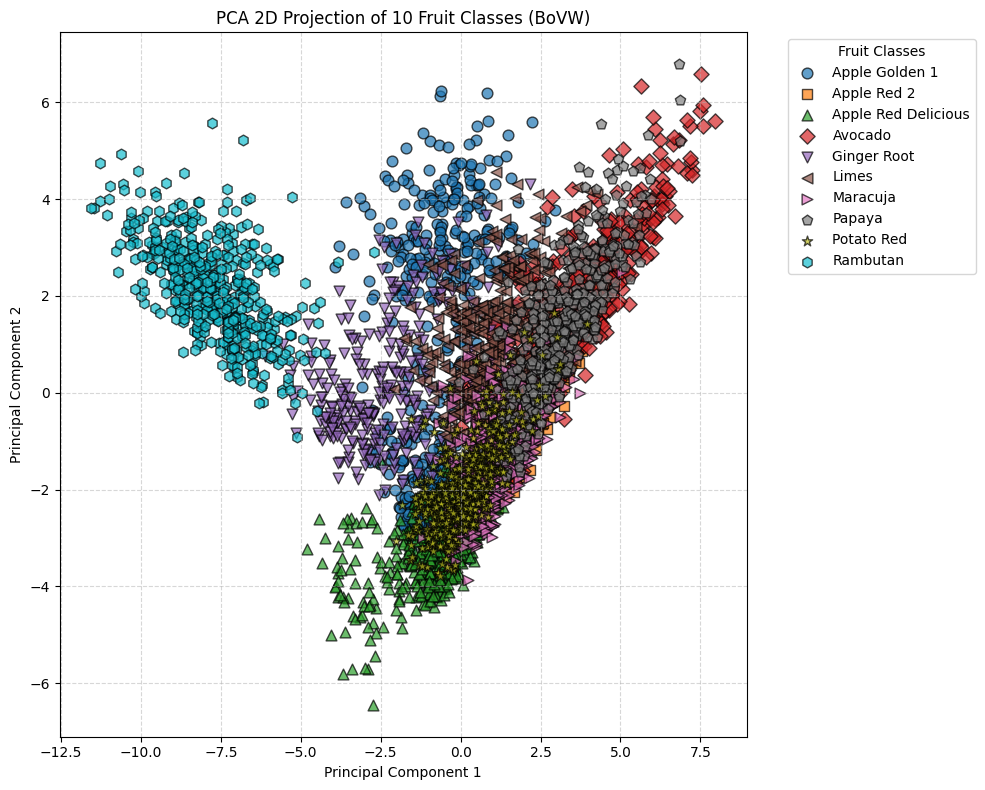

In [ ]:
import matplotlib.pyplot as plt

# Convert labels to a numpy array for indexing
labels_array = np.array(labels)

# Get the 10 unique class names
classes = np.unique(labels_array)

# Get a colormap with exactly 10 distinct colors
colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))
markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h'] # 10 distinct markers for better visibility

plt.figure(figsize=(10, 8))

# Loop through each of the 10 classes
for i, cls in enumerate(classes):
    # Find the row indices in pca_result where the label matches the current class
    idx = np.where(labels_array == cls)[0]
    
    # Scatter plot for this specific fruit class
    plt.scatter(
        pca_result[idx, 0],  # X coordinates
        pca_result[idx, 1],  # Y coordinates
        color=colors[i],     # Assign a unique color
        marker=markers[i],   # Assign a unique symbol
        label=cls,           # Label for the legend
        alpha=0.7,           # Slight transparency to see overlapping points
        edgecolors='k',      # Black border around points
        s=60                 # Size of the points
    )

# Formatting the plot
plt.title('PCA 2D Projection of 10 Fruit Classes (BoVW)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')

# Places the legend outside the plot so it doesn't cover the data
plt.legend(title="Fruit Classes", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout() # Adjusts layout so the legend isn't cut off
plt.show()

It is evident from the above figure that the Rambutan and Apple Red Delicious classes are the most separable from the rest of the classes. The Apple Golden 1 class shares common space with the Ginger Root and Limes classes. Additionally the Papaya, Potato Red, Apple Red 2, Maracuja, and Avocado classes significantly overlap and can't be separated.

<h1><b>3. Support Vector Machines </b></h1>